<a href="https://colab.research.google.com/github/MANSOURATOU/projet-livraison-olist/blob/main/notebooks/Projet_2_DA_Livraison_et_optimisation_satisfaction_client.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import pandas as pd
import os

# Téléchargement
path = kagglehub.dataset_download("jayeshsalunke101/brazilian-ecommerce-public-dataset")
print("Path to dataset files:", path)

# Lister tous les fichiers disponibles
print("\nFichiers disponibles :")
for f in os.listdir(path):
    print(" -", f)

100%|██████████| 42.7M/42.7M [00:03<00:00, 13.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jayeshsalunke101/brazilian-ecommerce-public-dataset/versions/1

Fichiers disponibles :
 - olist_customers_dataset.csv
 - olist_geolocation_dataset.csv
 - olist_order_reviews_dataset.csv
 - olist_products_dataset.csv
 - olist_orders_dataset.csv
 - olist_order_items_dataset.csv
 - olist_sellers_dataset.csv
 - olist_order_payments_dataset.csv
 - product_category_name_translation.csv


In [2]:
# Charger les fichiers clés
orders       = pd.read_csv(f"{path}/olist_orders_dataset.csv")
order_items  = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
products     = pd.read_csv(f"{path}/olist_products_dataset.csv")
customers    = pd.read_csv(f"{path}/olist_customers_dataset.csv")
reviews      = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
geolocation  = pd.read_csv(f"{path}/olist_geolocation_dataset.csv")

# Aperçu rapide de chaque table
dfs = {
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "customers": customers,
    "reviews": reviews,
    "geolocation": geolocation,
}

for name, df in dfs.items():
    print(f"\n{'='*40}")
    print(f"  {name.upper()} — {df.shape[0]:,} lignes, {df.shape[1]} colonnes")
    print(f"{'='*40}")
    print(df.dtypes)


  ORDERS — 99,441 lignes, 8 colonnes
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

  ORDER_ITEMS — 112,650 lignes, 7 colonnes
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

  PRODUCTS — 32,951 lignes, 9 colonnes
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_w

In [3]:
print(orders.head(3).to_string())
print("\nColonnes :")
print(orders.columns.tolist())

                           order_id                       customer_id order_status order_purchase_timestamp    order_approved_at order_delivered_carrier_date order_delivered_customer_date order_estimated_delivery_date
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15          2017-10-04 19:55:00           2017-10-10 21:25:13           2017-10-18 00:00:00
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27          2018-07-26 14:31:00           2018-08-07 15:27:45           2018-08-13 00:00:00
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23          2018-08-08 13:50:00           2018-08-17 18:06:29           2018-09-04 00:00:00

Colonnes :
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrie

In [4]:
# Convertir les dates (elles arrivent en string)
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Calculer les deux KPIs principaux du projet
orders["delai_reel_jours"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["ecart_estimation_jours"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days
# Positif = en retard, Négatif = en avance

orders["est_en_retard"] = orders["ecart_estimation_jours"] > 0

print(orders[["order_id", "delai_reel_jours", "ecart_estimation_jours", "est_en_retard"]].head(10))

                           order_id  delai_reel_jours  ecart_estimation_jours  \
0  e481f51cbdc54678b7cc49136f2d6af7               8.0                    -8.0   
1  53cdb2fc8bc7dce0b6741e2150273451              13.0                    -6.0   
2  47770eb9100c2d0c44946d9cf07ec65d               9.0                   -18.0   
3  949d5b44dbf5de918fe9c16f97b45f8a              13.0                   -13.0   
4  ad21c59c0840e6cb83a9ceb5573f8159               2.0                   -10.0   
5  a4591c265e18cb1dcee52889e2d8acc3              16.0                    -6.0   
6  136cce7faa42fdb2cefd53fdc79a6098               NaN                     NaN   
7  6514b8ad8028c9f2cc2374ded245783f               9.0                   -12.0   
8  76c6e866289321a7c93b82b54852dc33               9.0                   -32.0   
9  e69bfb5eb88e0ed6a785585b27e16dbf              18.0                    -7.0   

   est_en_retard  
0          False  
1          False  
2          False  
3          False  
4          Fa

In [5]:
livrees = orders[orders["order_status"] == "delivered"].copy()

print("=== KPIs globaux ===")
print(f"Commandes totales       : {len(orders):,}")
print(f"Commandes livrées       : {len(livrees):,}")
print(f"Délai moyen (jours)     : {livrees['delai_reel_jours'].mean():.1f}")
print(f"Délai médian (jours)    : {livrees['delai_reel_jours'].median():.1f}")
print(f"Taux de retard          : {livrees['est_en_retard'].mean()*100:.1f}%")
print(f"Retard moyen (si retard): {livrees[livrees['est_en_retard']]['ecart_estimation_jours'].mean():.1f} jours")

=== KPIs globaux ===
Commandes totales       : 99,441
Commandes livrées       : 96,478
Délai moyen (jours)     : 12.1
Délai médian (jours)    : 10.0
Taux de retard          : 6.8%
Retard moyen (si retard): 10.6 jours


In [6]:
# Joindre orders + reviews pour voir la corrélation retard / note
df = orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

# Note moyenne selon qu'on est en retard ou non
print("Note moyenne par statut :")
print(df.groupby("est_en_retard")["review_score"].mean().round(2))

# Note moyenne par délai (groupé par tranche)
df["tranche_delai"] = pd.cut(
    df["delai_reel_jours"],
    bins=[0, 7, 14, 21, 30, 60, 200],
    labels=["< 7j", "7-14j", "14-21j", "21-30j", "30-60j", "> 60j"]
)
print("\nNote moyenne par tranche de délai :")
print(df.groupby("tranche_delai", observed=True)["review_score"].mean().round(2))

Note moyenne par statut :
est_en_retard
False    4.20
True     2.26
Name: review_score, dtype: float64

Note moyenne par tranche de délai :
tranche_delai
< 7j      4.40
7-14j     4.28
14-21j    4.09
21-30j    3.48
30-60j    2.16
> 60j     2.13
Name: review_score, dtype: float64


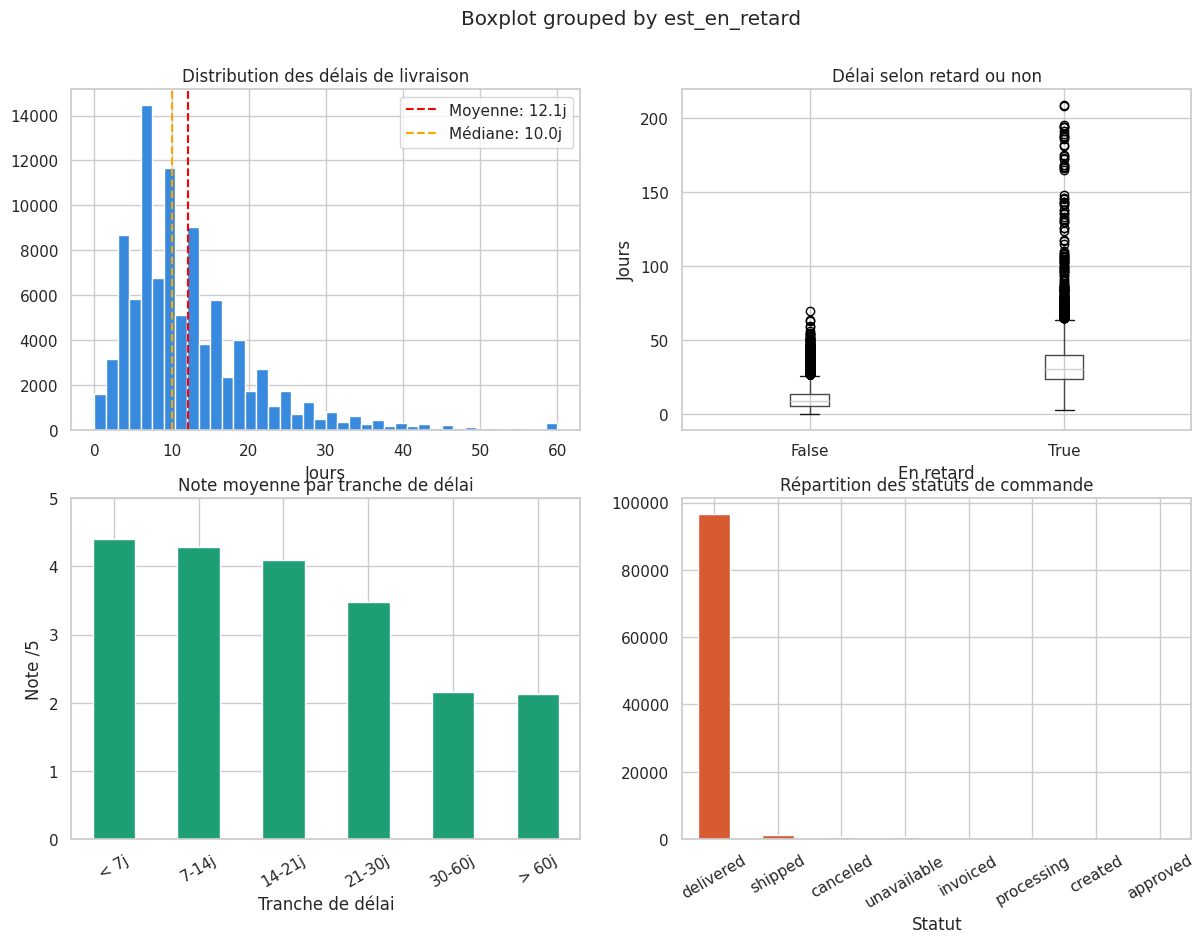

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style général
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA — Analyse des délais de livraison Olist", fontsize=14, fontweight="bold")

# 1. Distribution des délais réels
ax1 = axes[0, 0]
livrees["delai_reel_jours"].clip(0, 60).hist(bins=40, ax=ax1, color="#378ADD", edgecolor="white")
ax1.axvline(livrees["delai_reel_jours"].mean(), color="red", linestyle="--", label=f"Moyenne: {livrees['delai_reel_jours'].mean():.1f}j")
ax1.axvline(livrees["delai_reel_jours"].median(), color="orange", linestyle="--", label=f"Médiane: {livrees['delai_reel_jours'].median():.1f}j")
ax1.set_title("Distribution des délais de livraison")
ax1.set_xlabel("Jours")
ax1.legend()

# 2. Boxplot : délai par statut de retard
ax2 = axes[0, 1]
livrees.boxplot(column="delai_reel_jours", by="est_en_retard", ax=ax2)
ax2.set_title("Délai selon retard ou non")
ax2.set_xlabel("En retard")
ax2.set_ylabel("Jours")
plt.sca(ax2)
plt.title("Délai selon retard ou non")

# 3. Note moyenne par tranche de délai
ax3 = axes[1, 0]
df_plot = df.groupby("tranche_delai", observed=True)["review_score"].mean()
df_plot.plot(kind="bar", ax=ax3, color="#1D9E75", edgecolor="white")
ax3.set_title("Note moyenne par tranche de délai")
ax3.set_xlabel("Tranche de délai")
ax3.set_ylabel("Note /5")
ax3.set_ylim(0, 5)
ax3.tick_params(axis='x', rotation=30)

# 4. Répartition des statuts de commande
ax4 = axes[1, 1]
orders["order_status"].value_counts().plot(kind="bar", ax=ax4, color="#D85A30", edgecolor="white")
ax4.set_title("Répartition des statuts de commande")
ax4.set_xlabel("Statut")
ax4.tick_params(axis='x', rotation=30)

import os

# Créer le dossier s'il n'existe pas
os.makedirs("rapport", exist_ok=True)

# Ensuite sauvegarder normalement
plt.savefig("rapport/EDA_overview.png", dpi=150, bbox_inches="tight")
plt.show()

Top 10 états avec les délais les plus longs :
                delai_moyen  taux_retard  nb_commandes
customer_state                                        
RR                    28.98         0.12            41
AP                    26.73         0.03            67
AM                    25.99         0.03           145
AL                    24.04         0.21           397
PA                    23.32         0.11           946
MA                    21.12         0.17           717
SE                    21.03         0.15           335
CE                    20.82         0.14          1279
AC                    20.64         0.04            80
PB                    19.95         0.10           517


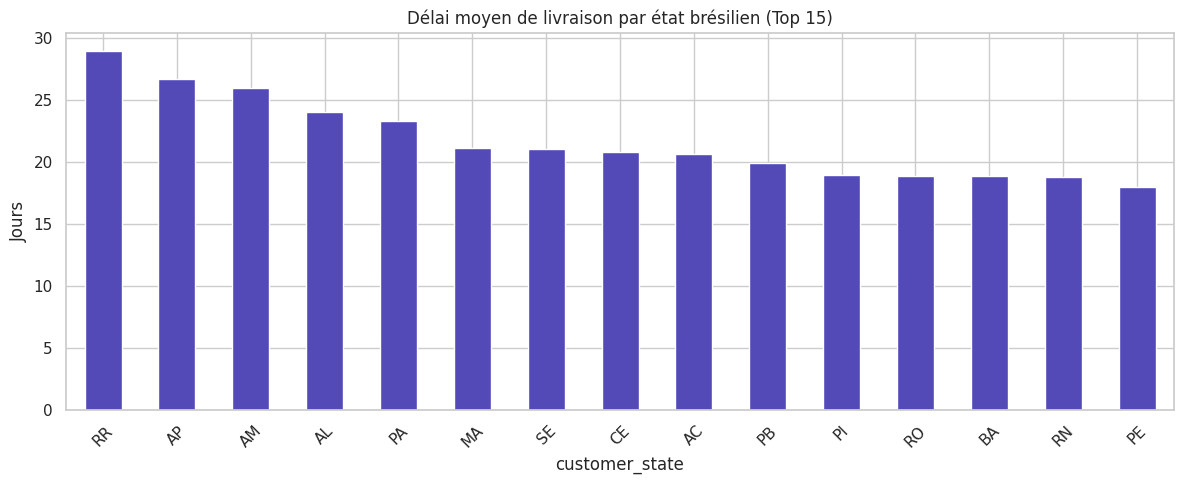

In [8]:
# Joindre orders + customers pour avoir la région
df_geo = livrees.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

# Délai moyen et taux de retard par état
by_state = df_geo.groupby("customer_state").agg(
    delai_moyen    = ("delai_reel_jours", "mean"),
    taux_retard    = ("est_en_retard", "mean"),
    nb_commandes   = ("order_id", "count")
).round(2).sort_values("delai_moyen", ascending=False)

print("Top 10 états avec les délais les plus longs :")
print(by_state.head(10))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
by_state["delai_moyen"].head(15).plot(kind="bar", ax=ax, color="#534AB7", edgecolor="white")
ax.set_title("Délai moyen de livraison par état brésilien (Top 15)")
ax.set_ylabel("Jours")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("rapport/delai_par_etat.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
import os
import pandas as pd

os.makedirs("data/processed", exist_ok=True)
os.makedirs("rapport", exist_ok=True)

# ── 1. Recharger et convertir les dates ──────────────────────────────────────
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# ── 2. Calculer tous les KPIs sur les commandes livrées ──────────────────────
df_etl = orders[orders["order_status"] == "delivered"].copy()

df_etl["delai_reel_jours"] = (
    df_etl["order_delivered_customer_date"] - df_etl["order_purchase_timestamp"]
).dt.days

df_etl["ecart_estimation_jours"] = (
    df_etl["order_delivered_customer_date"] - df_etl["order_estimated_delivery_date"]
).dt.days

df_etl["est_en_retard"]   = df_etl["ecart_estimation_jours"] > 0
df_etl["annee"]           = df_etl["order_purchase_timestamp"].dt.year
df_etl["mois"]            = df_etl["order_purchase_timestamp"].dt.month
df_etl["jour_semaine"]    = df_etl["order_purchase_timestamp"].dt.day_name()

# ── 3. Joindre order_items (fret, prix, seller) ───────────────────────────────
items_agg = order_items.groupby("order_id").agg(
    prix_total      = ("price", "sum"),
    fret_total      = ("freight_value", "sum"),
    nb_items        = ("order_item_id", "count"),
    seller_id       = ("seller_id", "first"),
    product_id      = ("product_id", "first"),
).reset_index()

df_etl = df_etl.merge(items_agg, on="order_id", how="left")

# ── 4. Joindre les produits (poids, catégorie) ────────────────────────────────
translation = pd.read_csv(f"{path}/product_category_name_translation.csv")
products_clean = products.merge(translation, on="product_category_name", how="left")
products_clean = products_clean[[
    "product_id", "product_category_name_english",
    "product_weight_g", "product_length_cm",
    "product_height_cm", "product_width_cm"
]]
products_clean["volume_cm3"] = (
    products_clean["product_length_cm"] *
    products_clean["product_height_cm"] *
    products_clean["product_width_cm"]
)

df_etl = df_etl.merge(products_clean, on="product_id", how="left")

# ── 5. Joindre les clients (état / ville) ─────────────────────────────────────
df_etl = df_etl.merge(
    customers[["customer_id", "customer_state", "customer_city"]],
    on="customer_id", how="left"
)

# ── 6. Joindre les vendeurs ───────────────────────────────────────────────────
sellers = pd.read_csv(f"{path}/olist_sellers_dataset.csv")
df_etl = df_etl.merge(
    sellers[["seller_id", "seller_state", "seller_city"]],
    on="seller_id", how="left"
)

# ── 7. Joindre les notes de satisfaction ─────────────────────────────────────
df_etl = df_etl.merge(
    reviews[["order_id", "review_score"]],
    on="order_id", how="left"
)

# ── 8. Supprimer les lignes sans dates (non livrées proprement) ───────────────
df_etl = df_etl.dropna(subset=["delai_reel_jours", "ecart_estimation_jours"])

# ── 9. Résumé qualité ────────────────────────────────────────────────────────
print("=== Résumé du dataset final ===")
print(f"Lignes          : {len(df_etl):,}")
print(f"Colonnes        : {df_etl.shape[1]}")
print(f"Valeurs nulles  :")
print(df_etl.isnull().sum()[df_etl.isnull().sum() > 0])

# ── 10. Export CSV pour Power BI ──────────────────────────────────────────────
output_path = "data/processed/olist_final.csv"
df_etl.to_csv(output_path, index=False)
print(f"\nFichier exporté : {output_path}")
print(df_etl.head(3).to_string())

=== Résumé du dataset final ===
Lignes          : 97,007
Colonnes        : 30
Valeurs nulles  :
order_approved_at                  14
order_delivered_carrier_date        1
product_category_name_english    1386
product_weight_g                   16
product_length_cm                  16
product_height_cm                  16
product_width_cm                   16
volume_cm3                         16
dtype: int64

Fichier exporté : data/processed/olist_final.csv
                           order_id                       customer_id order_status order_purchase_timestamp   order_approved_at order_delivered_carrier_date order_delivered_customer_date order_estimated_delivery_date  delai_reel_jours  ecart_estimation_jours  est_en_retard  annee  mois jour_semaine  prix_total  fret_total  nb_items                         seller_id                        product_id product_category_name_english  product_weight_g  product_length_cm  product_height_cm  product_width_cm  volume_cm3 customer_state cust

In [10]:
# Nettoyage final des nulles
df_etl["product_category_name_english"] = df_etl["product_category_name_english"].fillna("unknown")
df_etl[["product_weight_g", "product_length_cm",
        "product_height_cm", "product_width_cm", "volume_cm3"]] = df_etl[[
        "product_weight_g", "product_length_cm",
        "product_height_cm", "product_width_cm", "volume_cm3"]].fillna(0)

# Ré-exporter le CSV propre
df_etl.to_csv("data/processed/olist_final.csv", index=False)

# Vérification finale
print("Valeurs nulles restantes :")
print(df_etl.isnull().sum()[df_etl.isnull().sum() > 0])
print("\nDataset 100% prêt pour Power BI !")
print(f"Colonnes disponibles :\n{list(df_etl.columns)}")

Valeurs nulles restantes :
order_approved_at               14
order_delivered_carrier_date     1
dtype: int64

Dataset 100% prêt pour Power BI !
Colonnes disponibles :
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delai_reel_jours', 'ecart_estimation_jours', 'est_en_retard', 'annee', 'mois', 'jour_semaine', 'prix_total', 'fret_total', 'nb_items', 'seller_id', 'product_id', 'product_category_name_english', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'volume_cm3', 'customer_state', 'customer_city', 'seller_state', 'seller_city', 'review_score']


In [11]:
from google.colab import files
files.download("data/processed/olist_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>